# P1 · 07 — ARIMAX: giving ARIMA outside information

Plain (S)ARIMA only looks at the series' own past. **ARIMAX** adds **exogenous
regressors** $X_t$ — external variables that help explain $y_t$:

$$\phi(B)(1-B)^d\,(y_t - \beta^\top X_t) = \theta(B)\,\varepsilon_t.$$

We demonstrate two deterministic (fully reproducible) kinds of exog:

1. **Fourier terms** → smooth seasonality as sine/cosine regressors
   (*dynamic harmonic regression*) — an alternative to seasonal differencing.
2. **An intervention dummy** → a flag for the COVID quarters (2020 Q2/Q3) so the
   shock is *explained*, not baked into the trend.

A real driver (interest rate, monsoon, IIP) would plug into the exact same slot.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:  # silence statsmodels' chatty (harmless) convergence / lookup warnings
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from statsmodels.tsa.statespace.sarimax import SARIMAX
from src import baselines as B, backtest as bt, classical as C
q = data.load_quarterly(); nsa = q["gdp_nsa"]

### 1. Fourier seasonality (dynamic harmonic regression)

Instead of differencing away the season, we add Fourier pairs as regressors and let
ARIMA model the *non*-seasonal dynamics. We backtest it against the
seasonal-differencing SARIMA to see which wins.

In [2]:
fcs = {
    "seasonal_naive(4)":     B.seasonal_naive(4),
    "SARIMA(1,1,1)(0,1,0)4": C.sarima_forecaster((1, 1, 1), (0, 1, 0, 4)),
    "ARIMAX Fourier(2)":     C.arimax_forecaster((1, 1, 1), use_fourier=True, fourier_order=2),
    "ARIMAX Fourier(2)+covid": C.arimax_forecaster((1, 1, 1), use_fourier=True,
                                                   fourier_order=2, covid_dummy=True),
}
bt.compare(nsa, fcs, initial=40, h=4, step=1, season_length=4).round(3)

,MAE,RMSE,MAPE,sMAPE,MASE
"SARIMA(1,1,1)(0,1,0)4",2004034.387,4178715.528,3.693,3.763,0.612
ARIMAX Fourier(2),3333709.741,4321862.080,5.802,5.912,1.017
ARIMAX Fourier(2)+covid,3423233.154,4838853.249,5.974,5.929,1.045
seasonal_naive(4),4138715.808,4655608.591,7.221,7.392,1.263


On *this* series, **seasonal differencing (SARIMA) beats Fourier-ARIMAX.** That's an
important, non-obvious lesson:

* **Fourier** assumes a *fixed* seasonal shape and shines when the period is **large**
  (m = 52 weekly, m = 365 daily) where a seasonal difference would be wasteful or
  impossible to estimate.
* **Seasonal differencing** *adapts* to a slowly changing seasonal pattern and is
  ideal for small m (here m = 4). Right tool, right job.

The COVID dummy doesn't improve point accuracy either — which sets up the real
reason to use an intervention dummy: **diagnostics**, not the backtest.

### 2. The intervention dummy's real job: cleaning the 2020 shock

Fit ARIMA on the quarterly **YoY growth** with and without a COVID dummy, and look
at the **2020 residual**. Without the dummy, the −20%+ pandemic crash shows up as a
giant residual that distorts the variance and the AR estimates; with it, the shock
is absorbed by a coefficient and the residuals behave.

Max |residual| in 2020  without dummy: 31.4 pp
Max |residual| in 2020  with dummy   : 10.5 pp
Residual std    without / with       : 4.36 / 3.18
COVID dummy coefficient              : -23.0 pp (the modelled shock size)


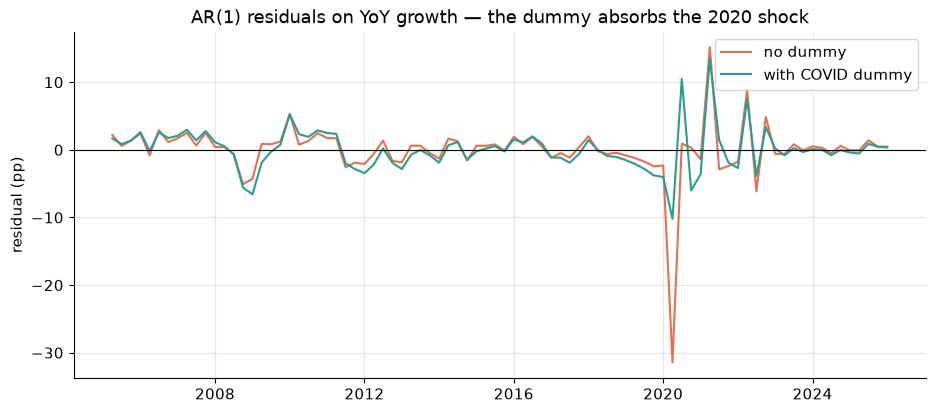

In [3]:
g = np.log(nsa).diff(4).dropna() * 100                 # YoY growth, %
g.index = g.index.to_timestamp(how="start")            # DatetimeIndex for clean access
covid = pd.DataFrame(
    {"covid": ((g.index.year == 2020) & (g.index.quarter.isin([2, 3]))).astype(float)},
    index=g.index)

# AR(1) with a constant (trend='c'), with and without the COVID exog
m_no = SARIMAX(g, order=(1, 0, 0), trend="c").fit(disp=False)
m_yes = SARIMAX(g, exog=covid, order=(1, 0, 0), trend="c").fit(disp=False)

resid_no, resid_yes = m_no.resid, m_yes.resid
print("Max |residual| in 2020  without dummy: %.1f pp" % resid_no.loc["2020"].abs().max())
print("Max |residual| in 2020  with dummy   : %.1f pp" % resid_yes.loc["2020"].abs().max())
print("Residual std    without / with       : %.2f / %.2f" % (resid_no.std(), resid_yes.std()))
print("COVID dummy coefficient              : %.1f pp (the modelled shock size)"
      % m_yes.params["covid"])

fig, ax = plt.subplots()
ax.plot(resid_no.index, resid_no.values, label="no dummy", color="#e76f51")
ax.plot(resid_yes.index, resid_yes.values, label="with COVID dummy", color="#2a9d8f")
ax.axhline(0, color="k", lw=0.8)
ax.set(title="AR(1) residuals on YoY growth — the dummy absorbs the 2020 shock",
       ylabel="residual (pp)"); ax.legend(); plt.show()

With the dummy, the monstrous 2020 residual collapses and the residual std shrinks —
the model is no longer fighting an event it was never going to predict. **That** is
when exogenous regressors earn their place: encoding *known* external facts (events,
policy changes, campaigns) so the stochastic part of the model stays clean. Whether
they improve out-of-sample *accuracy* is, as always, a question for the backtest.

---
**Next (08):** the capstone — bake **all** eight model families off against each
other and produce the final, defensible forecast.